# Gojek App Review Sentiment Analysis

This project analyzes 20,000 Gojek app reviews to identify user sentiment
and compare the performance of three machine learning algorithms:
Random Forest, Support Vector Machine (SVM), and Multinomial Naive Bayes.

The project also investigates the impact of class imbalance on sentiment
classification and derives business insights from user reviews.

## Project Objectives

1. Analyze the distribution of user ratings and sentiment.
2. Preprocess Indonesian-language app reviews.
3. Transform textual data using TF-IDF.
4. Compare Random Forest, SVM, and Naive Bayes.
5. Evaluate the impact of class imbalance handling.
6. Select the final model based on Macro F1.
7. Identify recurring themes and potential business insights from user feedback.

In [2]:
# ============================================
# IMPORT LIBRARY
# ============================================

# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import string

# NLP - Indonesian
!pip install Sastrawi
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Train-test split & evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Machine Learning models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 200)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 14.2 MB/s eta 0:00:00


In [3]:
# ============================================
# LOAD DATASET
# ============================================

# Membaca dataset review Gojek
df = pd.read_excel("/content/Kelompok 6_Hasil Crawling Review Gojek.xlsx")

# Menampilkan 5 data pertama
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,595da86c-acc1-4a64-ae43-90ff85eaf53d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,terlalu terlalu terlalu... apk yg tidak bisa di percaya. kuota cepat abis minta update terus. tp bug tmbah banyak. hp jd lelet !!!.. kok bisa nyuri data pribadi ya... diliat dari apk yg terus berj...,1,1,4.31.1,2022-04-21 13:37:07,"Hai, mohon maaf atas kendala yang kamu alami. Mengenai kendala tersebut, silakan laporkan melalui email ke customerservice@go-jek.com dengan melampirkan kode psr-22-112-0133-51987 pada subject ema...",2022-04-22 01:33:31,4.31.1
1,ceacdc70-b209-46d0-981f-ecbb8358722d,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,Tolong di perbaikin goride hemat nya selalu hilang terus²an padahal sebelumnya ada terus pake goride hemat sangat membantu saya karena bukan sekali atau 2 kali saya pakai tapi selalu pulang kerja ...,5,1,5.6.1,2024-12-24 10:50:50,NaN,NaT,5.6.1
2,14071b61-ead2-4ae6-9e50-a35ceea2662e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Padahal ya, selama ini konsisten selalu ada promo 10k di akunku untuk gofood tanpa minimal biaya, akhirnya krn mnrtku udah bagus nyoba beli paket plus. Baru seminggu pake tbtb promo 10k yg kmrn be...",1,3,5.4.1,2024-12-24 06:33:30,"Hai Kak @F L, mohon maaf atas ketidaknyamanannya. Mengenai promo mengikuti syarat dan ketentuan yang berlaku ya. Apabila voucher tersebut tidak digunakan & sudah melewati masa berlaku, maka secara...",2024-12-24 09:04:38,5.4.1
3,37315d45-e757-4fe8-ac2f-dc7be544337e,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Udah 3x pesen go ride selalu eror, segelah pesan dan sampai tujuan, lalu pesanan selesai tiba tiba ada driver lain yg tlf sudah sampai tujuan, padahal saya hanya pesan sekali tapi setiap pesan sel...",2,0,5.5.1,2024-12-24 05:21:44,"Hai Kak Dian, mohon maaf atas ketidaknyamanannya. Kedepannya jika terjadi double order kamu dapat melakukan pembatalan dari aplikasi untuk salah satu ordernya ya. Jika kamu memiliki pertanyaan ata...",2024-12-24 08:51:12,5.5.1
4,7cbc3868-2b7f-4a38-81c4-3a0e0bbbc989,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2NTXmTsBVtJqk8jxF9rh8ApRWfsIMQSt2uE4OcpQqbFu7f7NbTK05lx80nuSijCz7sc3a277R67g,"Aplikasi sangat membantu, tapi tolonglah ITnya perbaiki jarak jemput Jangan terlalu JAUH!!!!! Kasian PELANGGAN nunggu LAMA, dan kasian DRIVER juga Boros BBM, Tadak sesuai PENDAPATAN, dan sering ke...",5,173,5.5.1,2024-12-21 02:56:36,NaN,NaT,5.5.1


In [4]:
# Melihat jumlah baris dan kolom
print("Jumlah baris   :", df.shape[0])
print("Jumlah kolom   :", df.shape[1])

# Melihat nama kolom
print("\nNama kolom:")
print(df.columns.tolist())

Jumlah baris   : 20000
Jumlah kolom   : 11

Nama kolom:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [6]:
# Informasi tipe data dan jumlah non-null
df.info()

# Statistik deskriptif untuk kolom numerik
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              20000 non-null  object        
 1   userName              20000 non-null  object        
 2   userImage             20000 non-null  object        
 3   content               20000 non-null  object        
 4   score                 20000 non-null  int64         
 5   thumbsUpCount         20000 non-null  int64         
 6   reviewCreatedVersion  16547 non-null  object        
 7   at                    20000 non-null  datetime64[ns]
 8   replyContent          9498 non-null   object        
 9   repliedAt             9498 non-null   datetime64[ns]
 10  appVersion            16547 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 1.7+ MB


,score,thumbsUpCount,at,repliedAt
count,20000.0000,20000.000000,20000,9498
mean,2.3308,11.118750,2022-06-23 14:03:55.382599936,2023-06-11 18:37:12.891134976
min,1.0000,0.000000,2018-09-12 14:20:15,2017-09-20 09:06:43
25%,1.0000,0.000000,2020-08-20 01:28:38.500000,2022-04-26 01:05:41
50%,1.0000,0.000000,2022-08-17 12:55:23,2023-08-31 23:53:09
75%,4.0000,2.000000,2024-09-24 13:56:16,2024-10-21 22:12:41.750000128
max,5.0000,5829.000000,2024-12-24 15:38:44,2024-12-24 23:36:04
std,1.5911,94.877454,NaN,NaN


In [7]:
# Mengecek jumlah missing value setiap kolom
missing_values = df.isnull().sum()

print("Missing value setiap kolom:")
print(missing_values)

Missing value setiap kolom:
reviewId                    0
userName                    0
userImage                   0
content                     0
score                       0
thumbsUpCount               0
reviewCreatedVersion     3453
at                          0
replyContent            10502
repliedAt               10502
appVersion               3453
dtype: int64


In [8]:
# Mengecek duplikasi berdasarkan review ID
print("Duplikasi reviewId :", df['reviewId'].duplicated().sum())

# Mengecek duplikasi berdasarkan isi review
print("Duplikasi content  :", df['content'].duplicated().sum())

Duplikasi reviewId : 0
Duplikasi content  : 20


score
1    10072
2     2407
3     2216
4     1443
5     3862
Name: count, dtype: int64


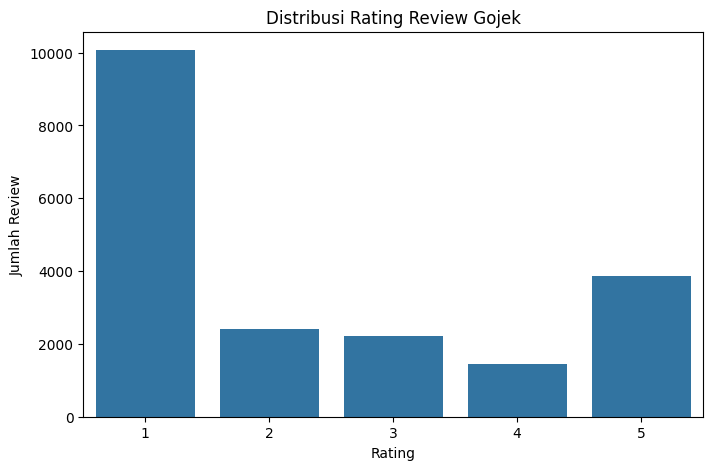

In [9]:
# Distribusi rating pengguna
rating_counts = df['score'].value_counts().sort_index()

print(rating_counts)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='score'
)

plt.title('Distribusi Rating Review Gojek')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

plt.show()

In [11]:
# ============================================
# MEMILIH VARIABEL ANALISIS
# ============================================

# Memilih kolom yang relevan untuk analisis
df = df[['content', 'score', 'at']].copy()

# Melihat struktur dataset setelah pemilihan kolom
print("Jumlah baris   :", df.shape[0])
print("Jumlah kolom   :", df.shape[1])

df.head()

Jumlah baris   : 20000
Jumlah kolom   : 3


,content,score,at
0,terlalu terlalu terlalu... apk yg tidak bisa di percaya. kuota cepat abis minta update terus. tp bug tmbah banyak. hp jd lelet !!!.. kok bisa nyuri data pribadi ya... diliat dari apk yg terus berj...,1,2022-04-21 13:37:07
1,Tolong di perbaikin goride hemat nya selalu hilang terus²an padahal sebelumnya ada terus pake goride hemat sangat membantu saya karena bukan sekali atau 2 kali saya pakai tapi selalu pulang kerja ...,5,2024-12-24 10:50:50
2,"Padahal ya, selama ini konsisten selalu ada promo 10k di akunku untuk gofood tanpa minimal biaya, akhirnya krn mnrtku udah bagus nyoba beli paket plus. Baru seminggu pake tbtb promo 10k yg kmrn be...",1,2024-12-24 06:33:30
3,"Udah 3x pesen go ride selalu eror, segelah pesan dan sampai tujuan, lalu pesanan selesai tiba tiba ada driver lain yg tlf sudah sampai tujuan, padahal saya hanya pesan sekali tapi setiap pesan sel...",2,2024-12-24 05:21:44
4,"Aplikasi sangat membantu, tapi tolonglah ITnya perbaiki jarak jemput Jangan terlalu JAUH!!!!! Kasian PELANGGAN nunggu LAMA, dan kasian DRIVER juga Boros BBM, Tadak sesuai PENDAPATAN, dan sering ke...",5,2024-12-21 02:56:36


In [12]:
# Mengecek tipe data
df.dtypes

,0
content,object
score,int64
at,datetime64[ns]


In [13]:
# Mengecek missing value
print("Missing value:")
print(df.isnull().sum())

# Mengecek duplikasi
print("\nDuplikasi:")
print("Duplikasi content :", df['content'].duplicated().sum())

Missing value:
content    0
score      0
at         0
dtype: int64

Duplikasi:
Duplikasi content : 20


In [14]:
# ============================================
# CELL 4A — SENTIMENT LABELING
# ============================================

def assign_sentiment(score):
    if score <= 2:
        return -1
    elif score == 3:
        return 0
    else:
        return 1

df['sentiment'] = df['score'].apply(assign_sentiment)

# Melihat beberapa hasil labeling
df[['score', 'sentiment']].head(10)

,score,sentiment
0,1,-1
1,5,1
2,1,-1
3,2,-1
4,5,1
5,2,-1
6,5,1
7,3,0
8,1,-1
9,1,-1


In [15]:
# Membuat label sentimen dalam bentuk teks
sentiment_mapping = {
    -1: 'Negative',
     0: 'Neutral',
     1: 'Positive'
}

df['sentiment_label'] = df['sentiment'].map(sentiment_mapping)

df[['score', 'sentiment', 'sentiment_label']].head(10)

,score,sentiment,sentiment_label
0,1,-1,Negative
1,5,1,Positive
2,1,-1,Negative
3,2,-1,Negative
4,5,1,Positive
5,2,-1,Negative
6,5,1,Positive
7,3,0,Neutral
8,1,-1,Negative
9,1,-1,Negative


In [16]:
# ============================================
# DISTRIBUSI SENTIMEN
# ============================================

sentiment_counts = (
    df['sentiment_label']
    .value_counts()
    .reindex(['Negative', 'Neutral', 'Positive'])
)

print("Distribusi Sentimen:")
print(sentiment_counts)

Distribusi Sentimen:
sentiment_label
Negative    12479
Neutral      2216
Positive     5305
Name: count, dtype: int64


In [17]:
sentiment_percentage = (
    df['sentiment_label']
    .value_counts(normalize=True)
    .reindex(['Negative', 'Neutral', 'Positive'])
    .mul(100)
    .round(2)
)

print("Persentase Sentimen:")
print(sentiment_percentage)

Persentase Sentimen:
sentiment_label
Negative    62.40
Neutral     11.08
Positive    26.52
Name: proportion, dtype: float64


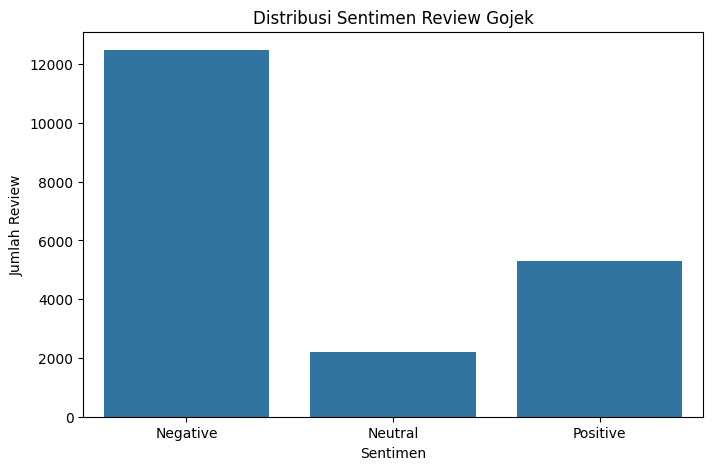

In [18]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values
)

plt.title('Distribusi Sentimen Review Gojek')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')

plt.show()

In [21]:
# ============================================
# INITIALIZE NLP TOOLS
# ============================================

# Stemming Bahasa Indonesia
stemmer_factory = StemmerFactory()
stemmer = stemmer_factory.create_stemmer()

# Stopword Bahasa Indonesia
stopword_factory = StopWordRemoverFactory()
stopwords = set(stopword_factory.get_stop_words())

print("Jumlah stopword:", len(stopwords))

Jumlah stopword: 123


In [22]:
# ============================================
# SLANG NORMALIZATION
# ============================================

slang_dictionary = {
    'gk': 'tidak',
    'ga': 'tidak',
    'gak': 'tidak',
    'nggak': 'tidak',
    'ngga': 'tidak',
    'enggak': 'tidak',
    'tdk': 'tidak',

    'yg': 'yang',
    'dgn': 'dengan',
    'dr': 'dari',
    'utk': 'untuk',
    'krn': 'karena',
    'karna': 'karena',

    'bgt': 'banget',
    'banget': 'banget',
    'bener': 'benar',
    'udh': 'sudah',
    'udah': 'sudah',
    'blm': 'belum',
    'belum': 'belum',

    'aja': 'saja',
    'jg': 'juga',
    'jga': 'juga',
    'sm': 'sama',
    'sma': 'sama',

    'tp': 'tapi',
    'tpi': 'tapi',
    'trs': 'terus',
    'trus': 'terus',

    'klo': 'kalau',
    'kalo': 'kalau',
    'kl': 'kalau',

    'bkn': 'bukan',
    'bs': 'bisa',
    'bisa': 'bisa',

    'apk': 'aplikasi',
    'apknya': 'aplikasinya'
}

In [23]:
# ============================================
# TEXT PREPROCESSING FUNCTION
# ============================================

def preprocess_text(text):
    # Pastikan data berupa string
    text = str(text)

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URL
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # 3. Normalisasi slang
    words = text.split()
    words = [slang_dictionary.get(word, word) for word in words]
    text = ' '.join(words)

    # 4. Remove punctuation dan angka
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    # 5. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 6. Tokenization
    tokens = text.split()

    # 7. Stopword removal
    tokens = [word for word in tokens if word not in stopwords]

    # 8. Stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # 9. Gabungkan kembali menjadi string
    return ' '.join(tokens)

In [24]:
# ============================================
# APPLY PREPROCESSING
# ============================================

df['cleaned_content'] = df['content'].apply(preprocess_text)

# Melihat hasil preprocessing
df[['content', 'cleaned_content']].head(10)

,content,cleaned_content
0,terlalu terlalu terlalu... apk yg tidak bisa di percaya. kuota cepat abis minta update terus. tp bug tmbah banyak. hp jd lelet !!!.. kok bisa nyuri data pribadi ya... diliat dari apk yg terus berj...,terlalu terlalu terlalu aplikasi percaya kuota cepat abis minta update terus bug tmbah banyak hp jd lelet kok nyuri data pribadi liat aplikasi terus berjln latar belakang terus kirim data g tau da...
1,Tolong di perbaikin goride hemat nya selalu hilang terus²an padahal sebelumnya ada terus pake goride hemat sangat membantu saya karena bukan sekali atau 2 kali saya pakai tapi selalu pulang kerja ...,perbaikin goride hemat nya selalu hilang terus an padahal belum terus pake goride hemat sangat bantu bukan sekali kali pakai selalu pulang kerja sangat hemat ongkos jadi baik
2,"Padahal ya, selama ini konsisten selalu ada promo 10k di akunku untuk gofood tanpa minimal biaya, akhirnya krn mnrtku udah bagus nyoba beli paket plus. Baru seminggu pake tbtb promo 10k yg kmrn be...",padahal lama konsisten selalu promo k akun gofood minimal biaya akhir mnrtku bagus nyoba beli paket plus baru minggu pake tbtb promo k kmrn bulan bulan selalu hilang kecewa bgt malah jadi lebih ma...
3,"Udah 3x pesen go ride selalu eror, segelah pesan dan sampai tujuan, lalu pesanan selesai tiba tiba ada driver lain yg tlf sudah sampai tujuan, padahal saya hanya pesan sekali tapi setiap pesan sel...",x sen go ride selalu eror gah pesan tuju lalu pesan selesai tiba tiba driver tlf tuju padahal pesan sekali pesan selalu orang kan kasi masalah x turut turut bgni terus dong benar
4,"Aplikasi sangat membantu, tapi tolonglah ITnya perbaiki jarak jemput Jangan terlalu JAUH!!!!! Kasian PELANGGAN nunggu LAMA, dan kasian DRIVER juga Boros BBM, Tadak sesuai PENDAPATAN, dan sering ke...",aplikasi sangat bantu tolong itnya baik jarak jemput jangan terlalu jauh kasi langgan nunggu lama kasi driver boros bbm tadak sesuai dapat sering kena cancel ayu donk baik jangan cuma mikirin untu...
5,"Tolong dong di upgrade sistem go food. Saya sudah menunggu lama tp malah tidak dapat driver akhirnya pesanan dibatalkan dan saya harus menunggu lama lagi. Kurang update, restoran sebenarnya sudah ...",dong upgrade sistem go food tunggu lama malah driver akhir pesan batal tunggu lama kurang update restoran benar tutup lihat tulis tutup awal mesan nunggu lama akhir batal buang waktu
6,"Tolong dong diperbaharui lagi system nya , masa setiap pesen gofood , gojek sama gocar selalu gak sesuai maps sama yang aku ketik manual. Padahal alamat nya sesuai tapi titik nya selalu tidak sesu...",dong baharu system nya masa sen gofood gojek sama gocar selalu sesuai maps sama aku ketik manual padahal alamat nya sesuai titik nya selalu sesuai iya kalau dapet driver erti bayar maki maki sama ...
7,"Aplikasi sedikit aneh, mau pakai yg paket apa saja tidak ada perbedaan nya saat order kendaraan, banyakkan driver tapi kasih yg jauh untuk menjemput dengan jarak yang di tuju lebih dekat.",aplikasi sedikit aneh mau pakai paket apa beda nya order kendara banyak driver kasih jauh jemput jarak tuju lebih dekat
8,"Gojek udah ga kayak dlu. Skrg ongkirnya mahal. Ongkir gofood untuk jarak 1 -2km kayak ongkir untuk jarak 7-10km. Trus ditambah ada biaya layanan juga. Kalo pake mode hemat, prosesnya lama banget. ...",gojek kayak dlu skrg ongkirnya mahal ongkir gofood jarak km kayak ongkir jarak km terus tambah biaya layan kalau pake mode hemat proses lama banget nunggu dapet drivernya terus goride kadang susah...
9,"Pesen gofood gak sengaja terpencet dan masih ada waktu untuk membatalkan pesanan, langsung saya klik opsi batalkan pesanan malah gak bisa/coba lagi. Gak jelas ni apk klo mmng gak bisa untuk dibata...",sen gofood sengaja pencet waktu batal pesan langsung klik opsi batal pesan malah coba jelas ni aplikasi kalau mmng batal buat opsi batal pesan percuma guna


In [25]:
# Mengecek jumlah data kosong setelah preprocessing
empty_processed = (df['cleaned_content'].str.strip() == '').sum()

print("Jumlah review kosong setelah preprocessing:", empty_processed)

Jumlah review kosong setelah preprocessing: 0


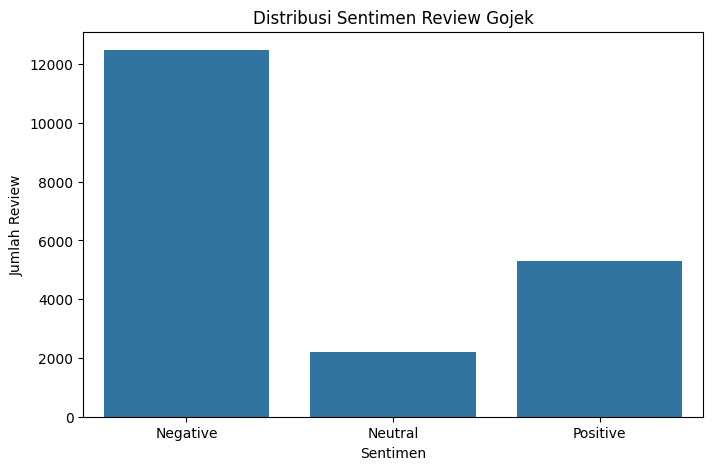

In [26]:
# ============================================
# DISTRIBUSI SENTIMEN
# ============================================

sentiment_order = ['Negative', 'Neutral', 'Positive']

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='sentiment_label',
    order=sentiment_order
)

plt.title('Distribusi Sentimen Review Gojek')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')

plt.show()

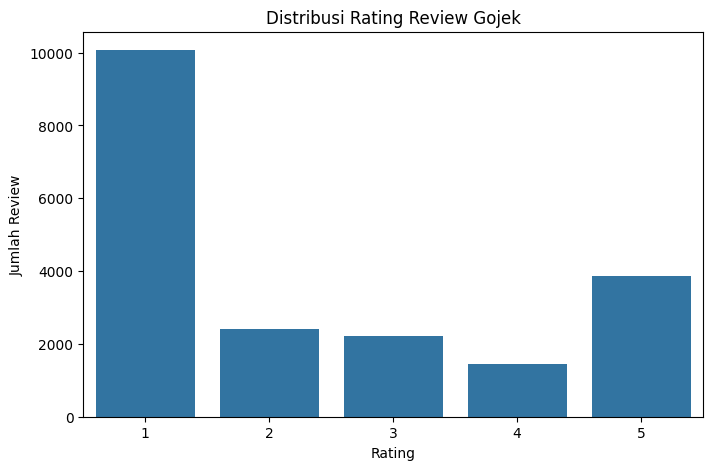

In [27]:
# ============================================
# DISTRIBUSI RATING
# ============================================

rating_order = [1, 2, 3, 4, 5]

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x='score',
    order=rating_order
)

plt.title('Distribusi Rating Review Gojek')
plt.xlabel('Rating')
plt.ylabel('Jumlah Review')

plt.show()

In [28]:
# ============================================
# RATING VS SENTIMENT
# ============================================

rating_sentiment = pd.crosstab(
    df['score'],
    df['sentiment_label']
).reindex(
    index=rating_order,
    columns=sentiment_order,
    fill_value=0
)

rating_sentiment

sentiment_label,Negative,Neutral,Positive
score,,,
1,10072,0,0
2,2407,0,0
3,0,2216,0
4,0,0,1443
5,0,0,3862


In [29]:
# ============================================
# KONVERSI TANGGAL
# ============================================

df['at'] = pd.to_datetime(df['at'])

print("Periode review:")
print("Mulai :", df['at'].min())
print("Sampai:", df['at'].max())

Periode review:
Mulai : 2018-09-12 14:20:15
Sampai: 2024-12-24 15:38:44


year
2018     868
2019    2691
2020    2435
2021    2650
2022    2230
2023    2030
2024    7096
Name: count, dtype: int64


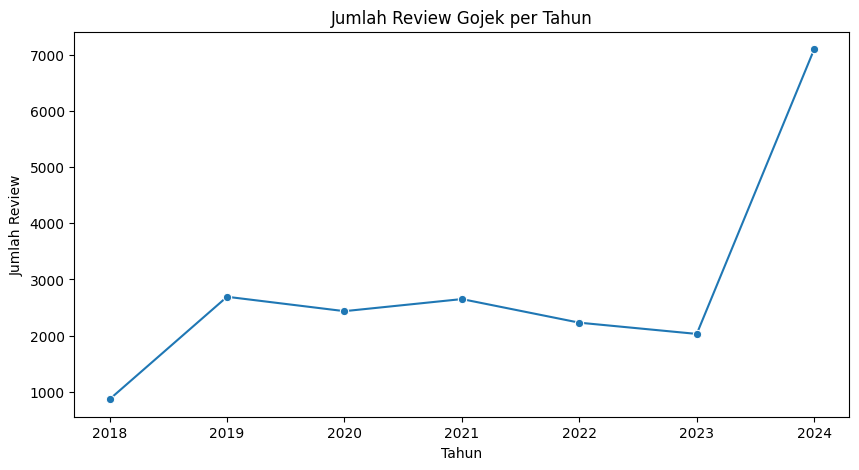

In [31]:
# ============================================
# JUMLAH REVIEW PER TAHUN
# ============================================

df['year'] = df['at'].dt.year

reviews_per_year = df['year'].value_counts().sort_index()

print(reviews_per_year)

plt.figure(figsize=(10, 5))

sns.lineplot(
    x=reviews_per_year.index,
    y=reviews_per_year.values,
    marker='o'
)

plt.title('Jumlah Review Gojek per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Review')

plt.xticks(reviews_per_year.index)

plt.show()

In [35]:
# ============================================
# SENTIMEN BERDASARKAN TAHUN
# ============================================

year_sentiment = pd.crosstab(
    df['year'],
    df['sentiment_label']
).reindex(
    columns=sentiment_order,
    fill_value=0
)

year_sentiment

sentiment_label,Negative,Neutral,Positive
year,,,
2018,397,189,282
2019,1420,401,870
2020,1647,252,536
2021,1885,277,488
2022,1491,294,445
2023,1504,236,290
2024,4135,567,2394


In [38]:
year_sentiment_percentage = (
    year_sentiment
    .div(year_sentiment.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

year_sentiment_percentage

sentiment_label,Negative,Neutral,Positive
year,,,
2018,45.74,21.77,32.49
2019,52.77,14.90,32.33
2020,67.64,10.35,22.01
2021,71.13,10.45,18.42
2022,66.86,13.18,19.96
2023,74.09,11.63,14.29
2024,58.27,7.99,33.74


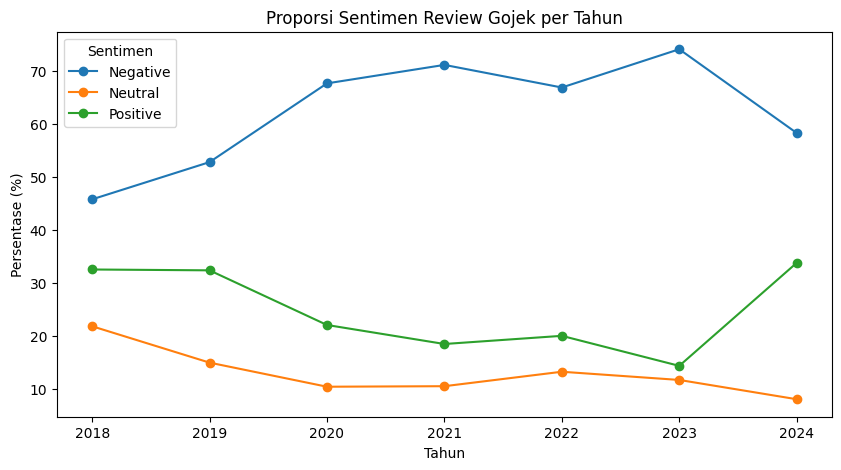

In [39]:
year_sentiment_percentage.plot(
    kind='line',
    figsize=(10, 5),
    marker='o'
)

plt.title('Proporsi Sentimen Review Gojek per Tahun')
plt.xlabel('Tahun')
plt.ylabel('Persentase (%)')

plt.legend(title='Sentimen')

plt.show()

In [40]:
# ============================================
# MENENTUKAN FITUR DAN TARGET
# ============================================

X = df['cleaned_content'].fillna('')
y = df['sentiment']

print("Jumlah data :", len(X))
print("Jumlah label:", len(y))

print("\nDistribusi label:")
print(y.value_counts().sort_index())

Jumlah data : 20000
Jumlah label: 20000

Distribusi label:
sentiment
-1    12479
 0     2216
 1     5305
Name: count, dtype: int64


In [41]:
# ============================================
# TRAIN TEST SPLIT
# ============================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Jumlah data training :", len(X_train))
print("Jumlah data testing  :", len(X_test))

Jumlah data training : 16000
Jumlah data testing  : 4000


In [42]:
# ============================================
# VALIDASI DISTRIBUSI TRAIN & TEST
# ============================================

train_distribution = (
    y_train.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

test_distribution = (
    y_test.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("Distribusi Training (%):")
print(train_distribution)

print("\nDistribusi Testing (%):")
print(test_distribution)

Distribusi Training (%):
sentiment
-1    62.39
 0    11.08
 1    26.52
Name: proportion, dtype: float64

Distribusi Testing (%):
sentiment
-1    62.40
 0    11.08
 1    26.52
Name: proportion, dtype: float64


In [43]:
# ============================================
# TF-IDF FEATURE EXTRACTION
# ============================================

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Shape TF-IDF training :", X_train_tfidf.shape)
print("Shape TF-IDF testing  :", X_test_tfidf.shape)

Shape TF-IDF training : (16000, 54710)
Shape TF-IDF testing  : (4000, 54710)


In [44]:
# ============================================
# CEK HASIL TF-IDF
# ============================================

print("Jumlah fitur TF-IDF:", len(tfidf.get_feature_names_out()))

print("\nContoh fitur:")
print(tfidf.get_feature_names_out()[:20])

Jumlah fitur TF-IDF: 54710

Contoh fitur:
['aamiin' 'ab' 'abad' 'abai' 'abai order' 'abai pesan' 'abal' 'abang'
 'abang abang' 'abang bilang' 'abang drivernya' 'abang go' 'abang gojek'
 'abang nunggu' 'abang nya' 'abang ojek' 'abang ojol' 'abang ojolnya'
 'abang ramah' 'abang sampe']


In [45]:
# ============================================
# RANDOM FOREST
# ============================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Training model
rf_model.fit(X_train_tfidf, y_train)

# Prediksi data testing
y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest selesai dilatih.")

Random Forest selesai dilatih.


In [46]:
# ============================================
# EVALUASI RANDOM FOREST
# ============================================

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average='macro',
    zero_division=0
)
recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average='macro',
    zero_division=0
)
f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average='macro',
    zero_division=0
)

print("=== RANDOM FOREST ===")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"Macro F1  : {f1_rf:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_rf,
        labels=[-1, 0, 1],
        target_names=['Negative', 'Neutral', 'Positive'],
        zero_division=0
    )
)

=== RANDOM FOREST ===
Accuracy  : 0.7540
Precision : 0.5327
Recall    : 0.5057
Macro F1  : 0.5004

Classification Report:
              precision    recall  f1-score   support

    Negative       0.73      0.98      0.84      2496
     Neutral       0.00      0.00      0.00       443
    Positive       0.87      0.54      0.66      1061

    accuracy                           0.75      4000
   macro avg       0.53      0.51      0.50      4000
weighted avg       0.69      0.75      0.70      4000



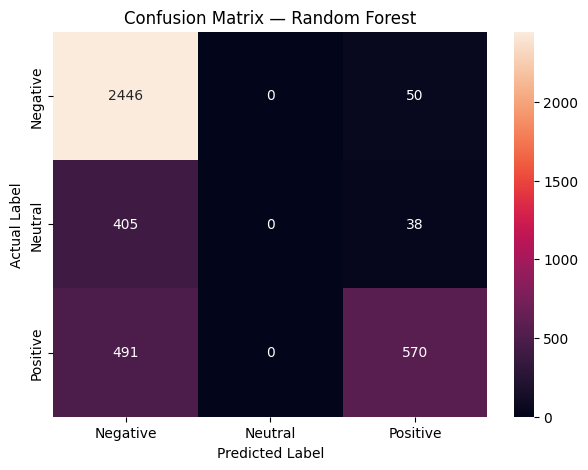

In [47]:
# ============================================
# CONFUSION MATRIX RANDOM FOREST
# ============================================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf,
    labels=[-1, 0, 1]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.title('Confusion Matrix — Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [48]:
# ============================================
# SUPPORT VECTOR MACHINE
# ============================================

svm_model = SVC(
    kernel='linear',
    random_state=42
)

# Training model
svm_model.fit(X_train_tfidf, y_train)

# Prediksi data testing
y_pred_svm = svm_model.predict(X_test_tfidf)

print("SVM selesai dilatih.")

SVM selesai dilatih.


In [49]:
# ============================================
# EVALUASI SVM
# ============================================

accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average='macro',
    zero_division=0
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average='macro',
    zero_division=0
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average='macro',
    zero_division=0
)

print("=== SUPPORT VECTOR MACHINE ===")
print(f"Accuracy  : {accuracy_svm:.4f}")
print(f"Precision : {precision_svm:.4f}")
print(f"Recall    : {recall_svm:.4f}")
print(f"Macro F1  : {f1_svm:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_svm,
        labels=[-1, 0, 1],
        target_names=['Negative', 'Neutral', 'Positive'],
        zero_division=0
    )
)

=== SUPPORT VECTOR MACHINE ===
Accuracy  : 0.7682
Precision : 0.6037
Recall    : 0.5353
Macro F1  : 0.5245

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.96      0.85      2496
     Neutral       0.25      0.01      0.01       443
    Positive       0.80      0.64      0.71      1061

    accuracy                           0.77      4000
   macro avg       0.60      0.54      0.52      4000
weighted avg       0.72      0.77      0.72      4000



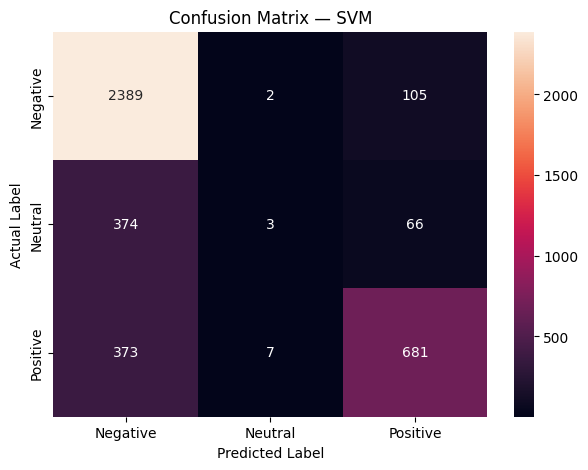

In [50]:
# ============================================
# CONFUSION MATRIX SVM
# ============================================

cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=[-1, 0, 1]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.title('Confusion Matrix — SVM')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [51]:
# ============================================
# NAIVE BAYES
# ============================================

nb_model = MultinomialNB()

# Training model
nb_model.fit(X_train_tfidf, y_train)

# Prediksi data testing
y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes selesai dilatih.")

Naive Bayes selesai dilatih.


In [52]:
# ============================================
# EVALUASI NAIVE BAYES
# ============================================

accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average='macro',
    zero_division=0
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average='macro',
    zero_division=0
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average='macro',
    zero_division=0
)

print("=== NAIVE BAYES ===")
print(f"Accuracy  : {accuracy_nb:.4f}")
print(f"Precision : {precision_nb:.4f}")
print(f"Recall    : {recall_nb:.4f}")
print(f"Macro F1  : {f1_nb:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred_nb,
        labels=[-1, 0, 1],
        target_names=['Negative', 'Neutral', 'Positive'],
        zero_division=0
    )
)

=== NAIVE BAYES ===
Accuracy  : 0.7157
Precision : 0.5549
Recall    : 0.4492
Macro F1  : 0.4430

Classification Report:
              precision    recall  f1-score   support

    Negative       0.69      1.00      0.82      2496
     Neutral       0.00      0.00      0.00       443
    Positive       0.98      0.35      0.51      1061

    accuracy                           0.72      4000
   macro avg       0.55      0.45      0.44      4000
weighted avg       0.69      0.72      0.64      4000



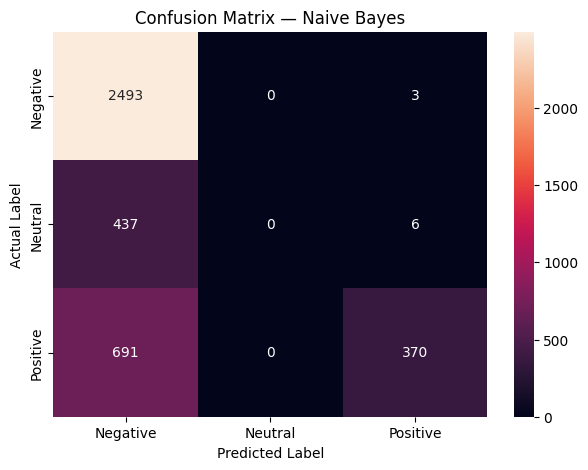

In [53]:
# ============================================
# CONFUSION MATRIX NAIVE BAYES
# ============================================

cm_nb = confusion_matrix(
    y_test,
    y_pred_nb,
    labels=[-1, 0, 1]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    xticklabels=['Negative', 'Neutral', 'Positive'],
    yticklabels=['Negative', 'Neutral', 'Positive']
)

plt.title('Confusion Matrix — Naive Bayes')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [54]:
# ============================================
# CELL 11 — MODEL COMPARISON
# ============================================

model_comparison = pd.DataFrame({
    'Model': [
        'Random Forest',
        'SVM',
        'Naive Bayes'
    ],
    'Accuracy': [
        accuracy_rf,
        accuracy_svm,
        accuracy_nb
    ],
    'Precision': [
        precision_rf,
        precision_svm,
        precision_nb
    ],
    'Recall': [
        recall_rf,
        recall_svm,
        recall_nb
    ],
    'Macro F1': [
        f1_rf,
        f1_svm,
        f1_nb
    ]
})

# Membulatkan hasil
model_comparison = model_comparison.round(4)

model_comparison

,Model,Accuracy,Precision,Recall,Macro F1
0,Random Forest,0.7540,0.5327,0.5057,0.5004
1,SVM,0.7682,0.6037,0.5353,0.5245
2,Naive Bayes,0.7158,0.5549,0.4492,0.4430


In [55]:
# ============================================
# RANKING MODEL
# ============================================

model_ranking = model_comparison.sort_values(
    by='Macro F1',
    ascending=False
).reset_index(drop=True)

model_ranking

,Model,Accuracy,Precision,Recall,Macro F1
0,SVM,0.7682,0.6037,0.5353,0.5245
1,Random Forest,0.7540,0.5327,0.5057,0.5004
2,Naive Bayes,0.7158,0.5549,0.4492,0.4430


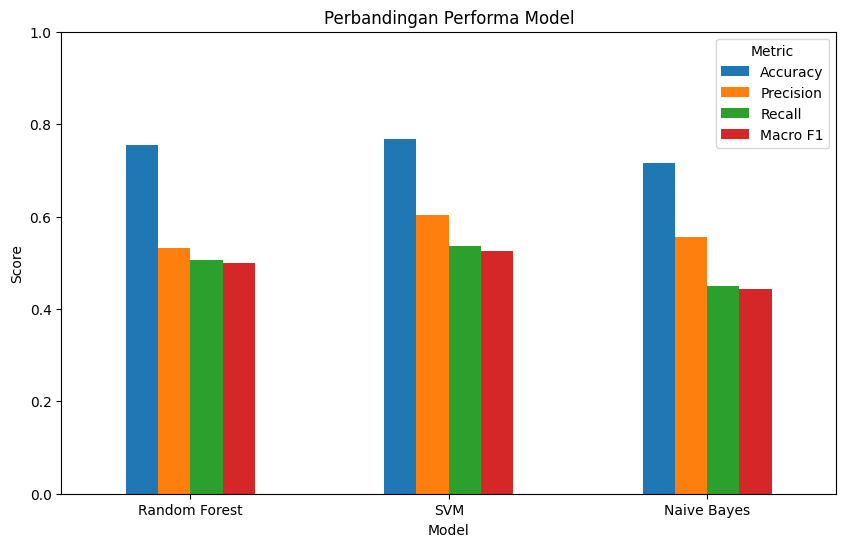

In [56]:
# ============================================
# VISUALISASI MODEL COMPARISON
# ============================================

comparison_plot = model_comparison.set_index('Model')[
    ['Accuracy', 'Precision', 'Recall', 'Macro F1']
]

comparison_plot.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Perbandingan Performa Model')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend(title='Metric')

plt.show()

In [57]:
# ============================================
# MAJORITY CLASS BASELINE
# ============================================

majority_class_accuracy = y_test.value_counts(normalize=True).max()

print(
    f"Majority Class Baseline Accuracy: "
    f"{majority_class_accuracy:.4f}"
)

Majority Class Baseline Accuracy: 0.6240


In [58]:
# ============================================
# HASIL PREDIKSI SVM
# ============================================

error_analysis = df.loc[X_test.index, [
    'content',
    'score',
    'sentiment_label'
]].copy()

# Menambahkan hasil prediksi SVM
error_analysis['predicted_sentiment'] = pd.Series(
    y_pred_svm,
    index=X_test.index
).map(sentiment_mapping)

# Menandai apakah prediksi benar atau salah
error_analysis['correct'] = (
    error_analysis['sentiment_label']
    == error_analysis['predicted_sentiment']
)

error_analysis.head(10)

,content,score,sentiment_label,predicted_sentiment,correct
5983,"Aplikasinya bagus, tetapi lebih bagus lagi kalau Aplikasi Driver, User/ Pengguna/ Penumpang, dan Go Food/ Go Resto dibuatkan gratis hanya pakai biaya kuota internet layanan Telpon, Chat (ganti sem...",5,Positive,Positive,True
15688,"Tolong perbaiki aplikasi nya yang kadang berat jd lag pdahal hp sy s22. Perbaiki juga kualitas driver-drivernya. Dan pas momen lebaran ini, ongkir gofood jadi selangit 😅",2,Negative,Negative,True
14283,Cukup untuk kekesalan saya yang susah dan memakan waktu lama untuk penolakan terus menerus upgrade !! . Aplikasi yang mengecewakan .,1,Negative,Negative,True
13791,"Awalnya sih bagus aplikasinya,tapi waktu mau coba isi gopay,malah ada tulisan gopay anda di blokir,sudah saya laporkan ke aplikasinya tapi ada tulisan kamu mendeteksi pembayaran yang tidak wajar,p...",3,Neutral,Negative,False
15779,"Mohon kedepannya untuk top up gopaynya ditambah e-wallet yang lain seperti DANA, OVO, atau QRIS biar lebih mudah jangan cuma menggunakan BankJAGO ama OneClickBCA aja... Untuk selebihnya sudah cuku...",4,Positive,Positive,True
17075,"Driver nya pada gak niat kerja. saya hampir 1 jam nunggu gak ada yg mau bawa pada di cancel in semua sama driver nya. Alhasil saya terlambat ke tempat kerja. Kalaupun karna jauh, saya bayar sesuai...",1,Negative,Negative,True
11700,"aplikasi 👍👍👍👍👍 saya sangat terbantu dgn adanya aplikasi ini. Saya yg ga bisa naik motor maupun nyetir, tetep bisa pergi ke mana2 dgn gocar. Dan waktu malas masak, bisa terbantu beli makanan lewat ...",5,Positive,Positive,True
1471,"Aplikasi GO-JEK sekarang nggak jelas, blokir playlater tanpa pemberitahuan dan konfirmasi. Padahal setiap bulan selalu saya bayar. NGACO",1,Negative,Negative,True
17089,"Untuk aduan bantuan kurang membantu, saldo gopay saya tidak kembali semestinya.. gara-gara saya pesan 2 porsi makanan di gofood yg tersedia dan yang datang cuma 1 porsi makanan.. sedangkan saldo g...",2,Negative,Negative,True
3331,Voucher yg disediakan sebenarnya bisa digunakan atau enggak ya? Soalnya minimal order sudah benar semua syarat dan ketentuan sudah memenuhi. Tapi harga tetap sama dan bukannya berkurang karna vouc...,1,Negative,Negative,True


In [59]:
# ============================================
# PREDICTION CORRECTNESS
# ============================================

prediction_summary = (
    error_analysis['correct']
    .value_counts()
    .rename(index={
        True: 'Correct',
        False: 'Incorrect'
    })
)

print(prediction_summary)

correct
Correct      3073
Incorrect     927
Name: count, dtype: int64


In [60]:
prediction_percentage = (
    error_analysis['correct']
    .value_counts(normalize=True)
    .rename(index={
        True: 'Correct',
        False: 'Incorrect'
    })
    .mul(100)
    .round(2)
)

print(prediction_percentage)

correct
Correct      76.82
Incorrect    23.18
Name: proportion, dtype: float64


In [61]:
# ============================================
# INCORRECT PREDICTIONS
# ============================================

incorrect_predictions = error_analysis[
    ~error_analysis['correct']
].copy()

print(
    "Jumlah prediksi salah:",
    len(incorrect_predictions)
)

incorrect_predictions.head(20)

Jumlah prediksi salah: 927


,content,score,sentiment_label,predicted_sentiment,correct
13791,"Awalnya sih bagus aplikasinya,tapi waktu mau coba isi gopay,malah ada tulisan gopay anda di blokir,sudah saya laporkan ke aplikasinya tapi ada tulisan kamu mendeteksi pembayaran yang tidak wajar,p...",3,Neutral,Negative,False
10098,"Kenapa gojek kalo topup gk bisa sekaligus 200k,,500k,,(kalo di Alfamart top up nya),,bahkan kalo top up 150k juga harus 2x transaksi, males bgt ya ,,gak praktis masa iya mau top up 150k kudu 2x tr...",3,Neutral,Negative,False
14035,Securenya masih kurang nih. saya pernah mengalami penarikan fiktif gopay ktnya pembelian otomatis aplikasi (jd ga bisa klaim) padahal saya ga ada langganan aplikasi apa2 yang link ke gojek. ngga a...,3,Neutral,Negative,False
9281,"Gak jelas banget sama promonya, saya sudah mengijuti s&k nya cuma kok gak terpotong yang pas pembayarannya? Promo 10k dengan minimal 25k pembelian........ Saya sudah ke resto mitra yang terdaftar ...",3,Neutral,Negative,False
6636,"Aplikasi udah bagus, kalo bisa kasih sangsi driver yg batalin pesanan sepihak,karna udah lama"" nunggu tiba"" dibatalin",4,Positive,Negative,False
3643,"Saran aja nih, kalau pesen gofood kadang titik sudah di tepatin, tp masih sering meleset Tolong dong untuk yg di mapsnya bisa di geser atau yg di tulisan titik pengirimannya bisa dirubah biar muda...",3,Neutral,Positive,False
2311,Layanan gosend nya baik yg motor atau mobil pada males drivernya. 4x cari driver gak nemu nemu.,2,Negative,Positive,False
16056,"Mohon untuk go mart disegerakan perbaikannya, karena memakai go daily barang yg dibutuhkan tidak lengkap. Beda sekali ketika menggunakan go mart. Terimakasih",3,Neutral,Negative,False
4386,Tolong segera dicarikan solusi banyak sekali driver yg datang tidak sesuai dengan aplikasi baik identitas driver maupun mobil. Penggunaan promo di alfamart blm bisa di akomodir krn kasirnya tidak ...,5,Positive,Negative,False
3221,"hampir semua ewallet saya punya dan itu premium semua proses upgradenya pun mudah dan tidak ribet, untuk yg ini minta ampun, sudah saya uninstal, tidak punya GOJEK kok dipikir malah ribet, untuk k...",1,Negative,Positive,False


In [62]:
# ============================================
# ERROR ANALYSIS: NEUTRAL
# ============================================

neutral_errors = incorrect_predictions[
    incorrect_predictions['sentiment_label'] == 'Neutral'
].copy()

print(
    "Jumlah review Neutral yang salah diprediksi:",
    len(neutral_errors)
)

neutral_errors.head(20)

Jumlah review Neutral yang salah diprediksi: 440


,content,score,sentiment_label,predicted_sentiment,correct
13791,"Awalnya sih bagus aplikasinya,tapi waktu mau coba isi gopay,malah ada tulisan gopay anda di blokir,sudah saya laporkan ke aplikasinya tapi ada tulisan kamu mendeteksi pembayaran yang tidak wajar,p...",3,Neutral,Negative,False
10098,"Kenapa gojek kalo topup gk bisa sekaligus 200k,,500k,,(kalo di Alfamart top up nya),,bahkan kalo top up 150k juga harus 2x transaksi, males bgt ya ,,gak praktis masa iya mau top up 150k kudu 2x tr...",3,Neutral,Negative,False
14035,Securenya masih kurang nih. saya pernah mengalami penarikan fiktif gopay ktnya pembelian otomatis aplikasi (jd ga bisa klaim) padahal saya ga ada langganan aplikasi apa2 yang link ke gojek. ngga a...,3,Neutral,Negative,False
9281,"Gak jelas banget sama promonya, saya sudah mengijuti s&k nya cuma kok gak terpotong yang pas pembayarannya? Promo 10k dengan minimal 25k pembelian........ Saya sudah ke resto mitra yang terdaftar ...",3,Neutral,Negative,False
3643,"Saran aja nih, kalau pesen gofood kadang titik sudah di tepatin, tp masih sering meleset Tolong dong untuk yg di mapsnya bisa di geser atau yg di tulisan titik pengirimannya bisa dirubah biar muda...",3,Neutral,Positive,False
16056,"Mohon untuk go mart disegerakan perbaikannya, karena memakai go daily barang yg dibutuhkan tidak lengkap. Beda sekali ketika menggunakan go mart. Terimakasih",3,Neutral,Negative,False
797,"Tolong dong perbaiki bug saat download bukti transaksi, masa di klik berkali kali gak bisa bisa download buktinya.",3,Neutral,Negative,False
8215,"bintang tiga dlu, soalnya ada masalah saat mau upgrade akun gopay, saat foto ktp udh ok, nah pada saat foto diri dan ktp, malah kembali sendiri, jadi gabisa upgrade akun. sudah coba setting ulang ...",3,Neutral,Negative,False
6154,"Didlm aplikasi ini ada mode hemat,ketika saya mencoba mode hemat estimasi pemesanan & pencarian driver 1jam lebih.saat makanan sdh sampai,makanan dingin tidak hangat lagi.jd intinya mode hemat ini...",3,Neutral,Negative,False
19763,Klw bisa yg punya aplikasi ojol . Jika pesan makanya wajib pake saldo di aplikasi untuk pembelian . . Untuk menghindari cancel order makanan . Kasian driver nya pak terima kasih,3,Neutral,Negative,False


In [63]:
# ============================================
# ARAH KESALAHAN SENTIMEN NEUTRAL
# ============================================

neutral_error_distribution = (
    neutral_errors['predicted_sentiment']
    .value_counts()
    .reindex(
        ['Negative', 'Neutral', 'Positive'],
        fill_value=0
    )
)

print(neutral_error_distribution)

predicted_sentiment
Negative    374
Neutral       0
Positive     66
Name: count, dtype: int64


In [64]:
# ============================================
# PERBANDINGAN PREDIKSI MODEL
# ============================================

model_predictions = pd.DataFrame({
    'Actual': y_test,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm,
    'Naive Bayes': y_pred_nb
}, index=X_test.index)

model_predictions.head(10)

,Actual,Random Forest,SVM,Naive Bayes
5983,1,-1,1,-1
15688,-1,-1,-1,-1
14283,-1,-1,-1,-1
13791,0,-1,-1,-1
15779,1,1,1,-1
17075,-1,-1,-1,-1
11700,1,1,1,1
1471,-1,-1,-1,-1
17089,-1,-1,-1,-1
3331,-1,-1,-1,-1


In [65]:
# ============================================
# PREDIKSI NEUTRAL OLEH 3 MODEL
# ============================================

neutral_predictions = model_predictions[
    model_predictions['Actual'] == 0
].copy()

neutral_predictions['Actual'] = (
    neutral_predictions['Actual']
    .map(sentiment_mapping)
)

neutral_predictions[['Actual', 'Random Forest', 'SVM', 'Naive Bayes']] = (
    neutral_predictions[
        ['Actual', 'Random Forest', 'SVM', 'Naive Bayes']
    ].replace(sentiment_mapping)
)

neutral_predictions.head(20)

,Actual,Random Forest,SVM,Naive Bayes
13791,Neutral,Negative,Negative,Negative
10098,Neutral,Negative,Negative,Negative
14035,Neutral,Negative,Negative,Negative
9281,Neutral,Negative,Negative,Negative
3643,Neutral,Positive,Positive,Negative
16056,Neutral,Positive,Negative,Negative
797,Neutral,Negative,Negative,Negative
8215,Neutral,Negative,Negative,Negative
6154,Neutral,Negative,Negative,Negative
19763,Neutral,Negative,Negative,Negative


In [66]:
# ============================================
# RANDOM FOREST BALANCED
# ============================================

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_balanced.fit(
    X_train_tfidf,
    y_train
)

y_pred_rf_balanced = rf_balanced.predict(
    X_test_tfidf
)

print("Random Forest Balanced selesai dilatih.")

Random Forest Balanced selesai dilatih.


In [67]:
# ============================================
# CELL 13B — SVM BALANCED
# ============================================

svm_balanced = SVC(
    kernel='linear',
    class_weight='balanced',
    random_state=42
)

svm_balanced.fit(
    X_train_tfidf,
    y_train
)

y_pred_svm_balanced = svm_balanced.predict(
    X_test_tfidf
)

print("SVM Balanced selesai dilatih.")

SVM Balanced selesai dilatih.


In [68]:
from sklearn.utils.class_weight import compute_sample_weight
# ============================================
# NAIVE BAYES BALANCED
# ============================================

sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

nb_balanced = MultinomialNB()

nb_balanced.fit(
    X_train_tfidf,
    y_train,
    sample_weight=sample_weights
)

y_pred_nb_balanced = nb_balanced.predict(
    X_test_tfidf
)

print("Naive Bayes Balanced selesai dilatih.")

Naive Bayes Balanced selesai dilatih.


In [69]:
# ============================================
# EVALUASI MODEL BALANCED
# ============================================

balanced_results = []

balanced_models = {
    'Random Forest Balanced': y_pred_rf_balanced,
    'SVM Balanced': y_pred_svm_balanced,
    'Naive Bayes Balanced': y_pred_nb_balanced
}

for model_name, predictions in balanced_models.items():

    accuracy = accuracy_score(
        y_test,
        predictions
    )

    precision = precision_score(
        y_test,
        predictions,
        average='macro',
        zero_division=0
    )

    recall = recall_score(
        y_test,
        predictions,
        average='macro',
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        predictions,
        average='macro',
        zero_division=0
    )

    balanced_results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'Macro F1': f1
    })

balanced_comparison = pd.DataFrame(
    balanced_results
).round(4)

balanced_comparison

,Model,Accuracy,Precision,Recall,Macro F1
0,Random Forest Balanced,0.7500,0.5255,0.5038,0.4975
1,SVM Balanced,0.7128,0.5625,0.5563,0.5592
2,Naive Bayes Balanced,0.6582,0.6036,0.5941,0.5768


In [70]:
# ============================================
# CLASSIFICATION REPORT
# ============================================

print("=== RANDOM FOREST BALANCED ===")

print(
    classification_report(
        y_test,
        y_pred_rf_balanced,
        labels=[-1, 0, 1],
        target_names=[
            'Negative',
            'Neutral',
            'Positive'
        ],
        zero_division=0
    )
)

print("\n=== SVM BALANCED ===")

print(
    classification_report(
        y_test,
        y_pred_svm_balanced,
        labels=[-1, 0, 1],
        target_names=[
            'Negative',
            'Neutral',
            'Positive'
        ],
        zero_division=0
    )
)

print("\n=== NAIVE BAYES BALANCED ===")

print(
    classification_report(
        y_test,
        y_pred_nb_balanced,
        labels=[-1, 0, 1],
        target_names=[
            'Negative',
            'Neutral',
            'Positive'
        ],
        zero_division=0
    )
)

=== RANDOM FOREST BALANCED ===
              precision    recall  f1-score   support

    Negative       0.73      0.97      0.83      2496
     Neutral       0.00      0.00      0.00       443
    Positive       0.85      0.54      0.66      1061

    accuracy                           0.75      4000
   macro avg       0.53      0.50      0.50      4000
weighted avg       0.68      0.75      0.70      4000


=== SVM BALANCED ===
              precision    recall  f1-score   support

    Negative       0.81      0.83      0.82      2496
     Neutral       0.17      0.17      0.17       443
    Positive       0.71      0.67      0.69      1061

    accuracy                           0.71      4000
   macro avg       0.56      0.56      0.56      4000
weighted avg       0.71      0.71      0.71      4000


=== NAIVE BAYES BALANCED ===
              precision    recall  f1-score   support

    Negative       0.84      0.71      0.77      2496
     Neutral       0.19      0.45      0.27   

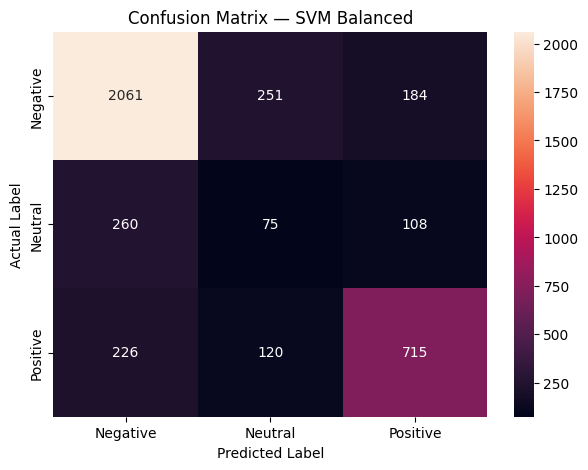

In [71]:
# ============================================
# CONFUSION MATRIX SVM BALANCED
# ============================================

cm_svm_balanced = confusion_matrix(
    y_test,
    y_pred_svm_balanced,
    labels=[-1, 0, 1]
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm_svm_balanced,
    annot=True,
    fmt='d',
    xticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ],
    yticklabels=[
        'Negative',
        'Neutral',
        'Positive'
    ]
)

plt.title('Confusion Matrix — SVM Balanced')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.show()

In [72]:
# ============================================
# FINAL MODEL COMPARISON
# ============================================

baseline_comparison = model_comparison.copy()

balanced_comparison = balanced_comparison.copy()

final_comparison = pd.concat(
    [
        baseline_comparison,
        balanced_comparison
    ],
    ignore_index=True
)

final_comparison = final_comparison.sort_values(
    by='Macro F1',
    ascending=False
).reset_index(drop=True)

final_comparison

,Model,Accuracy,Precision,Recall,Macro F1
0,Naive Bayes Balanced,0.6582,0.6036,0.5941,0.5768
1,SVM Balanced,0.7128,0.5625,0.5563,0.5592
2,SVM,0.7682,0.6037,0.5353,0.5245
3,Random Forest,0.7540,0.5327,0.5057,0.5004
4,Random Forest Balanced,0.7500,0.5255,0.5038,0.4975
5,Naive Bayes,0.7158,0.5549,0.4492,0.4430


In [73]:
# ============================================
# MODEL RANKING
# ============================================

final_comparison['Rank'] = (
    final_comparison['Macro F1']
    .rank(
        method='min',
        ascending=False
    )
    .astype(int)
)

final_comparison = final_comparison.sort_values(
    by='Rank'
).reset_index(drop=True)

final_comparison

,Model,Accuracy,Precision,Recall,Macro F1,Rank
0,Naive Bayes Balanced,0.6582,0.6036,0.5941,0.5768,1
1,SVM Balanced,0.7128,0.5625,0.5563,0.5592,2
2,SVM,0.7682,0.6037,0.5353,0.5245,3
3,Random Forest,0.7540,0.5327,0.5057,0.5004,4
4,Random Forest Balanced,0.7500,0.5255,0.5038,0.4975,5
5,Naive Bayes,0.7158,0.5549,0.4492,0.4430,6


In [74]:
# ============================================
# FINAL MODEL
# ============================================

best_model_name = final_comparison.loc[
    0,
    'Model'
]

best_macro_f1 = final_comparison.loc[
    0,
    'Macro F1'
]

print("Final Model :", best_model_name)
print(f"Macro F1    : {best_macro_f1:.4f}")

Final Model : Naive Bayes Balanced
Macro F1    : 0.5768


In [76]:
# ============================================
# CELL 15F — PERFORMANSI PER KELAS
# ============================================

report_final = classification_report(
    y_test,
    y_pred_final,
    labels=[-1, 0, 1],
    target_names=[
        'Negative',
        'Neutral',
        'Positive'
    ],
    output_dict=True,
    zero_division=0
)

class_performance = pd.DataFrame(
    report_final
).transpose()

class_performance = class_performance.loc[
    ['Negative', 'Neutral', 'Positive'],
    ['precision', 'recall', 'f1-score', 'support']
]

class_performance.round(4)

,precision,recall,f1-score,support
Negative,0.8366,0.7115,0.7690,2496.0
Neutral,0.1931,0.4515,0.2705,443.0
Positive,0.7812,0.6192,0.6909,1061.0


In [77]:
# ============================================
# SENTIMENT DISTRIBUTION
# ============================================

sentiment_summary = (
    df.groupby('sentiment_label')
    .size()
    .reindex(['Negative', 'Neutral', 'Positive'])
    .reset_index(name='Review Count')
)

sentiment_summary['Percentage'] = (
    sentiment_summary['Review Count']
    / sentiment_summary['Review Count'].sum()
    * 100
).round(2)

sentiment_summary

,sentiment_label,Review Count,Percentage
0,Negative,12479,62.40
1,Neutral,2216,11.08
2,Positive,5305,26.52


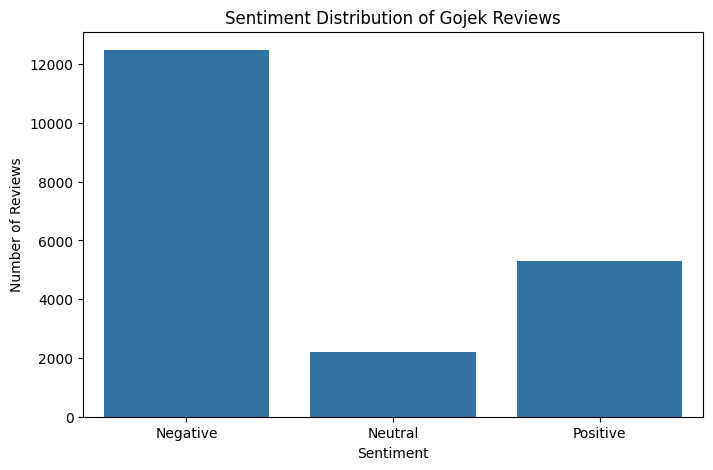

In [78]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=sentiment_summary,
    x='sentiment_label',
    y='Review Count',
    order=['Negative', 'Neutral', 'Positive']
)

plt.title('Sentiment Distribution of Gojek Reviews')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [79]:
# ============================================
# TOP WORDS PER SENTIMENT
# ============================================

from collections import Counter

def get_top_words(data, n=15):
    words = ' '.join(data).split()
    return Counter(words).most_common(n)

for sentiment in ['Negative', 'Neutral', 'Positive']:

    top_words = get_top_words(
        df.loc[
            df['sentiment_label'] == sentiment,
            'cleaned_content'
        ],
        n=15
    )

    print(f"\n=== {sentiment.upper()} ===")

    for word, count in top_words:
        print(f"{word}: {count}")


=== NEGATIVE ===
aplikasi: 8019
driver: 6368
nya: 6023
gojek: 4868
kalau: 3864
mau: 3848
padahal: 3598
pesan: 3281
sama: 2979
jadi: 2948
malah: 2947
lama: 2932
gopay: 2601
order: 2414
baik: 2331

=== NEUTRAL ===
driver: 1280
aplikasi: 1210
nya: 1185
kalau: 892
gojek: 869
jadi: 670
mau: 649
padahal: 633
pesan: 590
baik: 560
sama: 485
lama: 449
lebih: 443
order: 421
sering: 386

=== POSITIVE ===
aplikasi: 2739
nya: 2108
driver: 1996
gojek: 1992
sangat: 1523
kalau: 1445
bantu: 1236
baik: 1188
lebih: 1128
jadi: 1065
bagus: 957
go: 932
pesan: 890
banyak: 886
mau: 883


In [82]:
# ============================================
# CELL 16C — TOP BIGRAM PER SENTIMENT
# ============================================

from collections import Counter

def get_top_bigrams(data, n=15):

    bigrams = []

    for text in data:
        words = text.split()

        for i in range(len(words) - 1):
            bigrams.append(
                f"{words[i]} {words[i+1]}"
            )

    return Counter(bigrams).most_common(n)


for sentiment in ['Negative', 'Neutral', 'Positive']:

    top_bigrams = get_top_bigrams(
        df.loc[
            df['sentiment_label'] == sentiment,
            'cleaned_content'
        ],
        n=15
    )

    print(f"\n=== {sentiment.upper()} ===")

    for bigram, count in top_bigrams:
        print(f"{bigram}: {count}")


=== NEGATIVE ===
aplikasi gojek: 698
driver nya: 539
go food: 510
sangat kecewa: 507
top up: 493
sama sekali: 478
aplikasi nya: 441
tiba tiba: 398
saldo gopay: 389
aplikasi belah: 302
gopay plus: 299
go jek: 297
pesan gofood: 291
cari driver: 285
kalau mau: 284

=== NEUTRAL ===
aplikasi gojek: 125
driver nya: 121
go food: 105
aplikasi nya: 93
kasih bintang: 84
top up: 80
kalau mau: 80
terima kasih: 75
tiba tiba: 62
sangat bantu: 62
mohon baik: 58
dapet driver: 56
cari driver: 56
go ride: 56
saldo gopay: 51

=== POSITIVE ===
sangat bantu: 778
aplikasi gojek: 315
terima kasih: 290
aplikasi sangat: 244
go jek: 239
go food: 225
driver nya: 218
aplikasi nya: 196
aplikasi bagus: 163
lebih baik: 143
banyak promo: 129
guna aplikasi: 118
bantu sekali: 115
go ride: 108
lebih mudah: 106


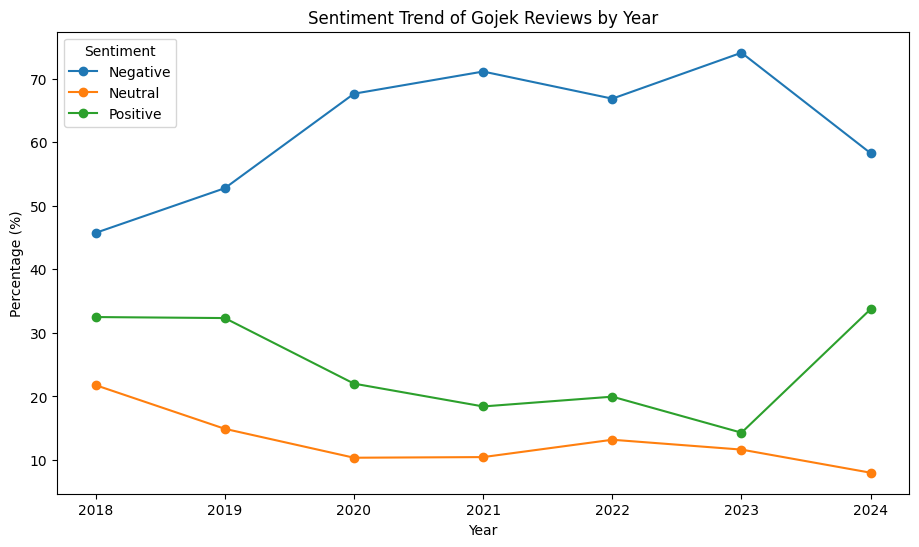

In [83]:
plt.figure(figsize=(11, 6))

for sentiment in ['Negative', 'Neutral', 'Positive']:
    plt.plot(
        year_sentiment_percentage.index,
        year_sentiment_percentage[sentiment],
        marker='o',
        label=sentiment
    )

plt.title('Sentiment Trend of Gojek Reviews by Year')
plt.xlabel('Year')
plt.ylabel('Percentage (%)')

plt.legend(title='Sentiment')
plt.xticks(year_sentiment_percentage.index)

plt.show()

In [84]:
# ============================================
# TOP WORDS NEGATIVE REVIEWS
# ============================================

negative_words = get_top_words(
    df.loc[
        df['sentiment_label'] == 'Negative',
        'cleaned_content'
    ],
    n=20
)

negative_words_df = pd.DataFrame(
    negative_words,
    columns=['Word', 'Frequency']
)

negative_words_df

,Word,Frequency
0,aplikasi,8019
1,driver,6368
2,nya,6023
3,gojek,4868
4,kalau,3864
5,mau,3848
6,padahal,3598
7,pesan,3281
8,sama,2979
9,jadi,2948


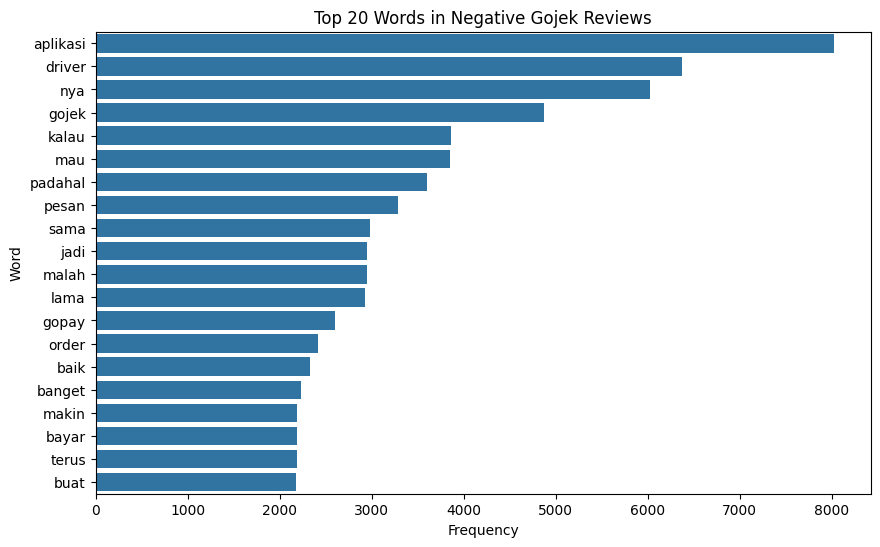

In [85]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=negative_words_df,
    x='Frequency',
    y='Word'
)

plt.title('Top 20 Words in Negative Gojek Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

In [86]:
# ============================================
# TOP WORDS POSITIVE REVIEWS
# ============================================

positive_words = get_top_words(
    df.loc[
        df['sentiment_label'] == 'Positive',
        'cleaned_content'
    ],
    n=20
)

positive_words_df = pd.DataFrame(
    positive_words,
    columns=['Word', 'Frequency']
)

positive_words_df

,Word,Frequency
0,aplikasi,2739
1,nya,2108
2,driver,1996
3,gojek,1992
4,sangat,1523
5,kalau,1445
6,bantu,1236
7,baik,1188
8,lebih,1128
9,jadi,1065


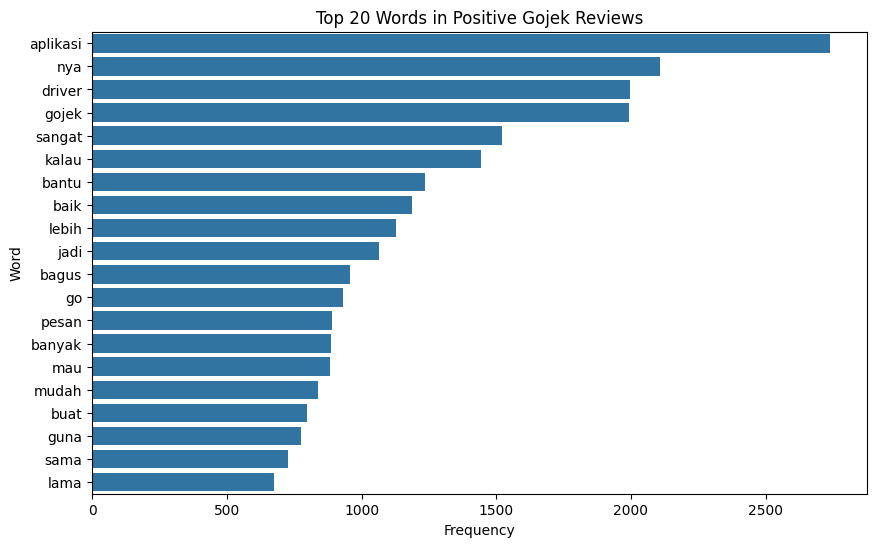

In [87]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=positive_words_df,
    x='Frequency',
    y='Word'
)

plt.title('Top 20 Words in Positive Gojek Reviews')
plt.xlabel('Frequency')
plt.ylabel('Word')

plt.show()

In [88]:
from wordcloud import WordCloud

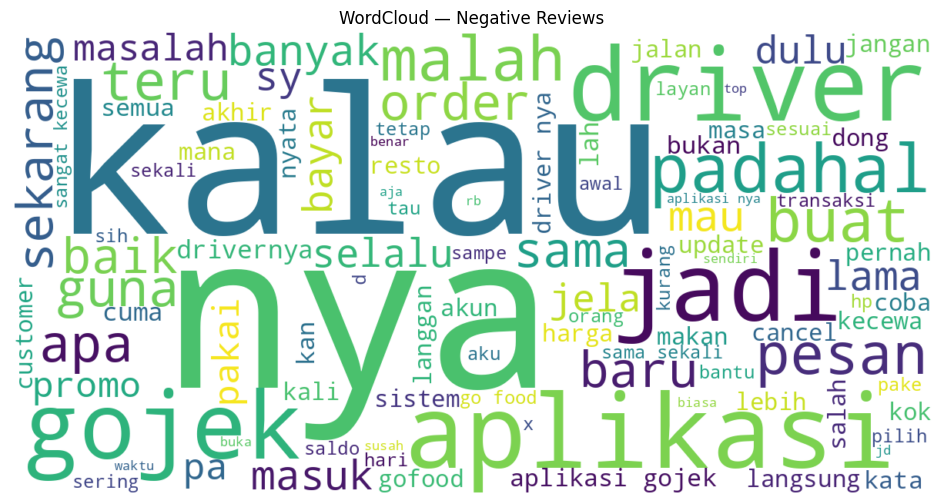

In [89]:
# ============================================
# CELL 16I — WORDCLOUD NEGATIVE
# ============================================

negative_text = ' '.join(
    df.loc[
        df['sentiment_label'] == 'Negative',
        'cleaned_content'
    ]
)

wordcloud_negative = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud_negative,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('WordCloud — Negative Reviews')

plt.show()

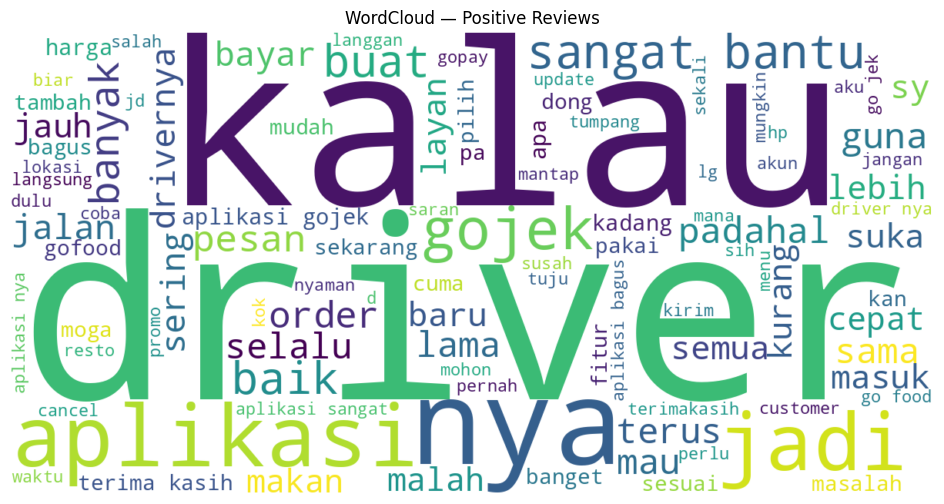

In [90]:
# ============================================
# WORDCLOUD POSITIVE
# ============================================

positive_text = ' '.join(
    df.loc[
        df['sentiment_label'] == 'Positive',
        'cleaned_content'
    ]
)

wordcloud_positive = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud_positive,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('WordCloud — Positive Reviews')

plt.show()

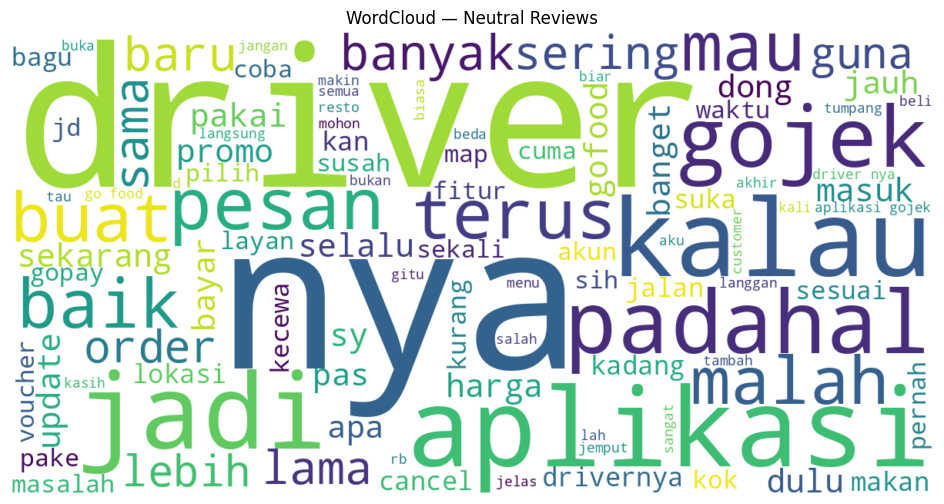

In [91]:
# ============================================
# WORDCLOUD NEUTRAL
# ============================================

neutral_text = ' '.join(
    df.loc[
        df['sentiment_label'] == 'Neutral',
        'cleaned_content'
    ]
)

wordcloud_neutral = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=100
).generate(neutral_text)

plt.figure(figsize=(12, 6))

plt.imshow(
    wordcloud_neutral,
    interpolation='bilinear'
)

plt.axis('off')

plt.title('WordCloud — Neutral Reviews')

plt.show()